Importing libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

Load dataset

In [3]:
df = pd.read_csv("Unemployment in India.csv")

Data Inspection

In [4]:
df.head()

df.tail()

df.shape

df.info()

df.describe()

df.columns

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


np.int64(27)

In [5]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

Missing values

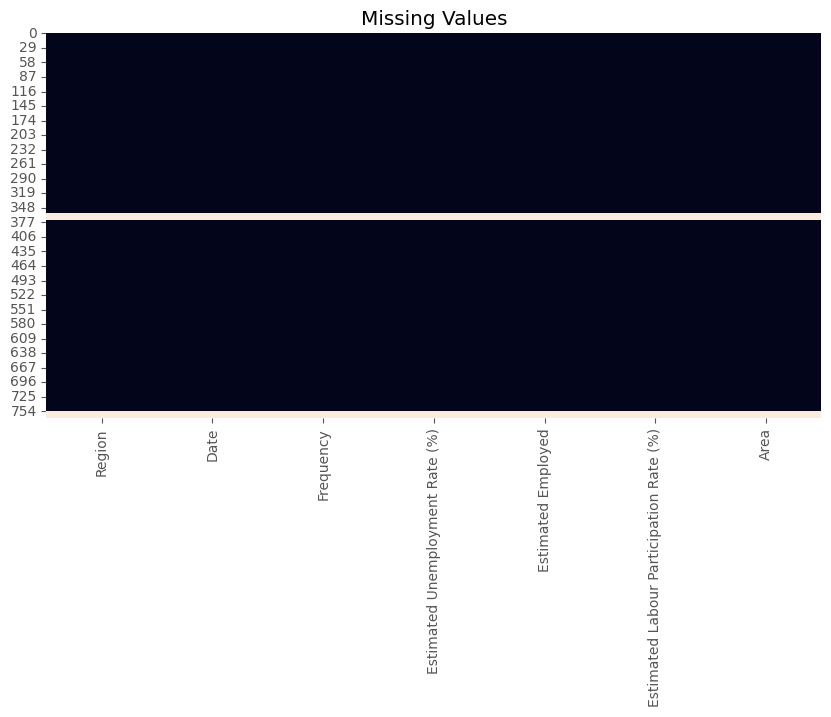

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Values")

plt.show()

In [8]:
df = df.dropna()

Unemployment Distribution

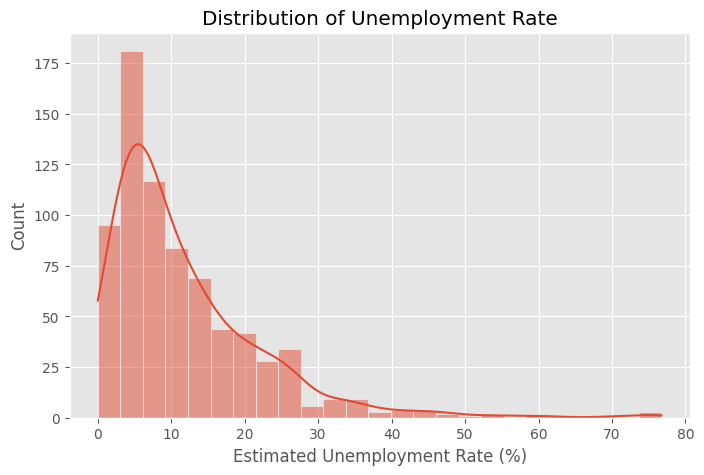

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=25,
    kde=True
)

plt.title("Distribution of Unemployment Rate")

plt.show()

Region-wise Average Unemployment

In [10]:
state=df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

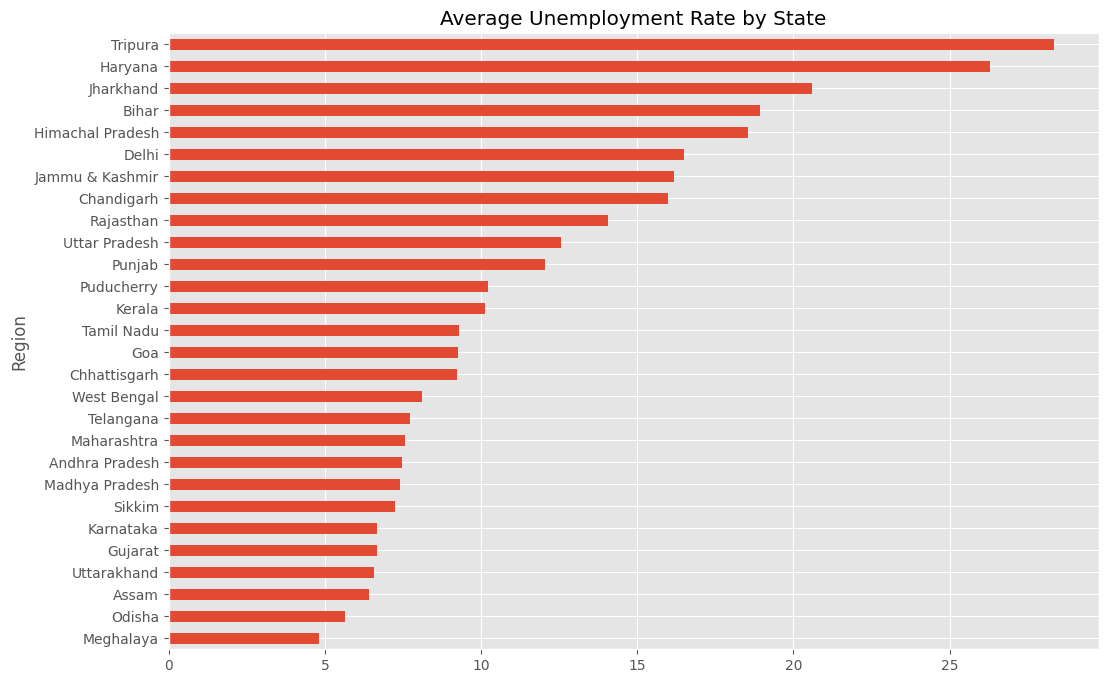

In [11]:
plt.figure(figsize=(12,8))

state.plot(kind="barh")

plt.title("Average Unemployment Rate by State")

plt.show()

Top 10 Highest Unemployment States

In [12]:
top10=state.sort_values(ascending=False).head(10)

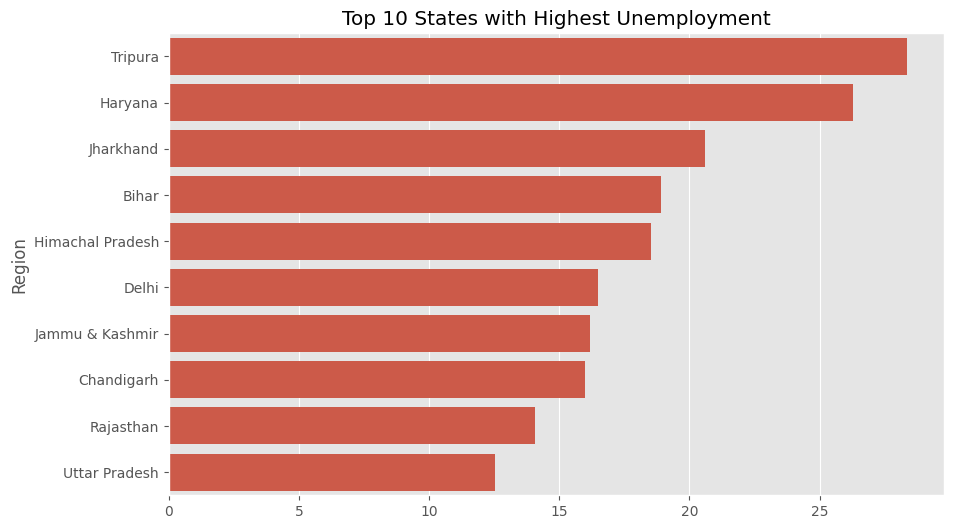

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States with Highest Unemployment")

plt.show()

Monthly Trend

In [14]:
df['Month']=df['Date'].dt.month_name()

In [15]:
monthly=df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

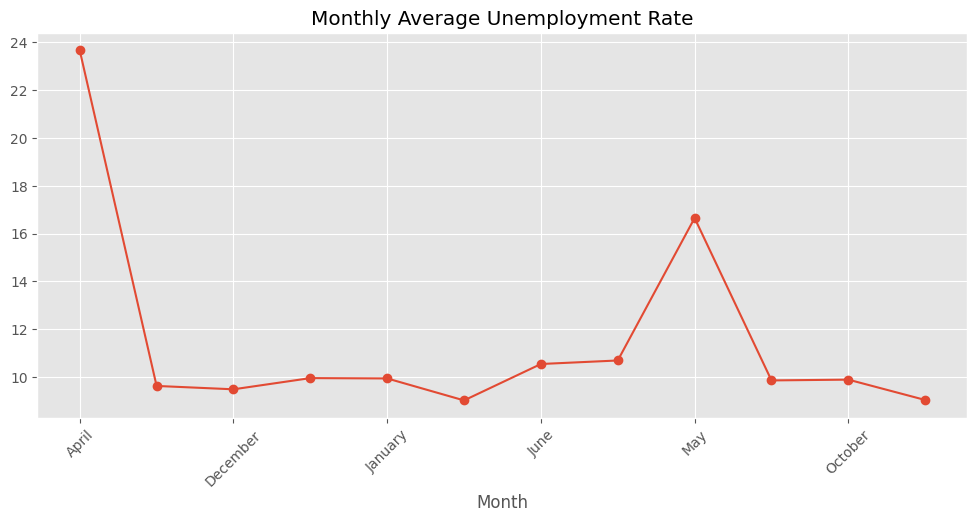

In [16]:
plt.figure(figsize=(12,5))

monthly.plot(marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Average Unemployment Rate")

plt.show()

Time Series (3 Major States)

In [17]:
states=[
'Delhi',
'Maharashtra',
'Tamil Nadu'
]

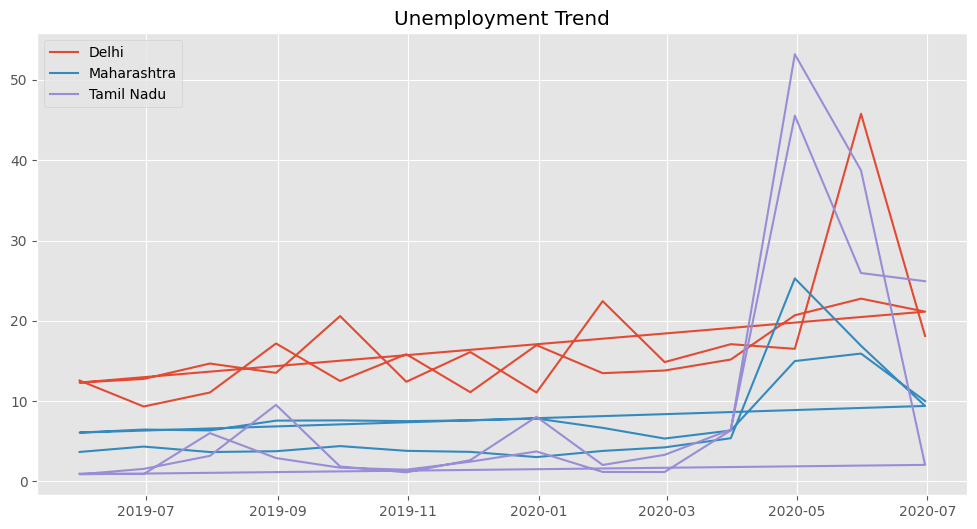

In [18]:
plt.figure(figsize=(12,6))

for state in states:

    temp=df[df['Region']==state]

    plt.plot(
        temp['Date'],
        temp['Estimated Unemployment Rate (%)'],
        label=state
    )

plt.legend()

plt.title("Unemployment Trend")

plt.show()

Labour Participation vs Employment

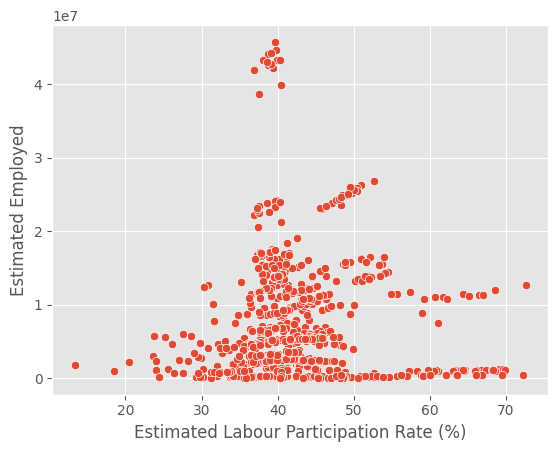

In [19]:
sns.scatterplot(

x='Estimated Labour Participation Rate (%)',

y='Estimated Employed',

data=df

)

plt.show()

Correlation Heatmap

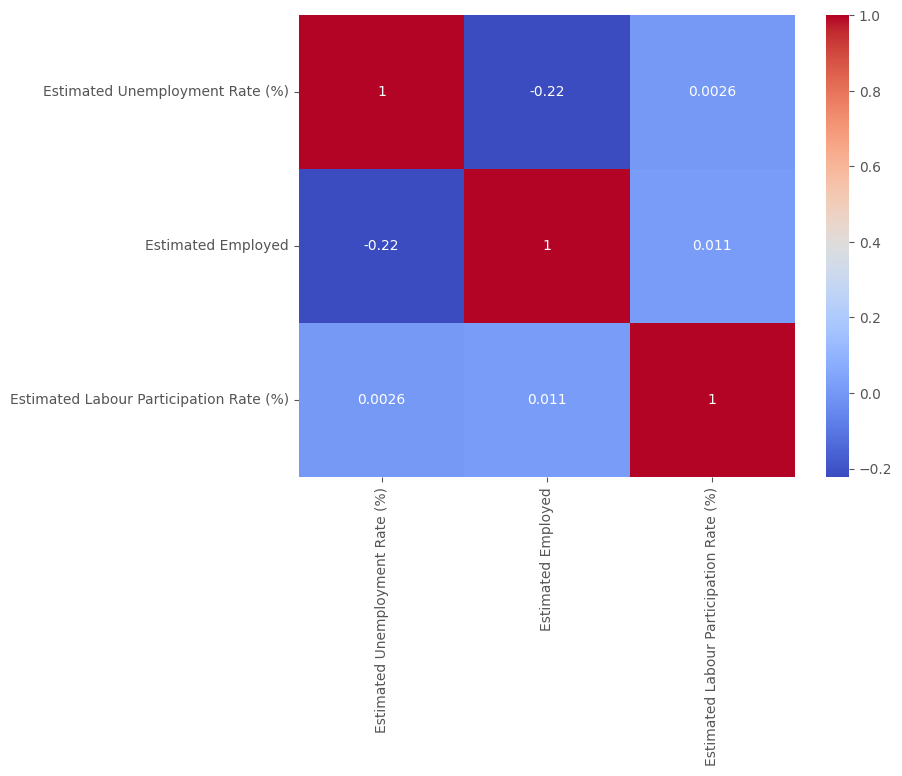

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(

df.select_dtypes(include=np.number).corr(),

annot=True,

cmap='coolwarm'

)

plt.show()

Pre-COVID vs Post-COVID

In [21]:
covid='2020-03-01'

In [22]:
pre=df[df['Date']<covid]

post=df[df['Date']>=covid]

In [23]:
print(pre['Estimated Unemployment Rate (%)'].mean())

print(post['Estimated Unemployment Rate (%)'].mean())

9.509533582089553
17.774362745098042


In [24]:
comparison=pd.DataFrame({

'Period':['Pre COVID','Post COVID'],

'Average Unemployment':[

pre['Estimated Unemployment Rate (%)'].mean(),

post['Estimated Unemployment Rate (%)'].mean()

]

})

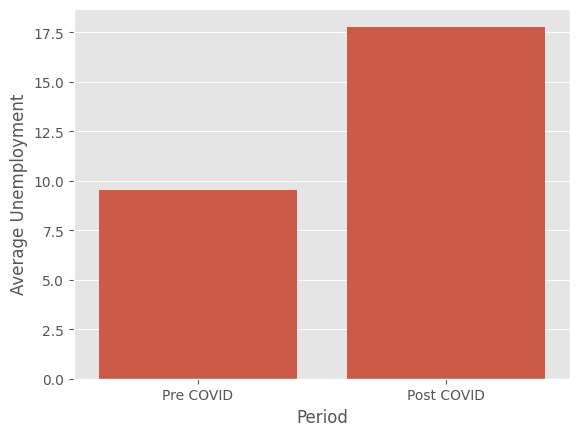

In [25]:
sns.barplot(

data=comparison,

x='Period',

y='Average Unemployment'

)

plt.show()

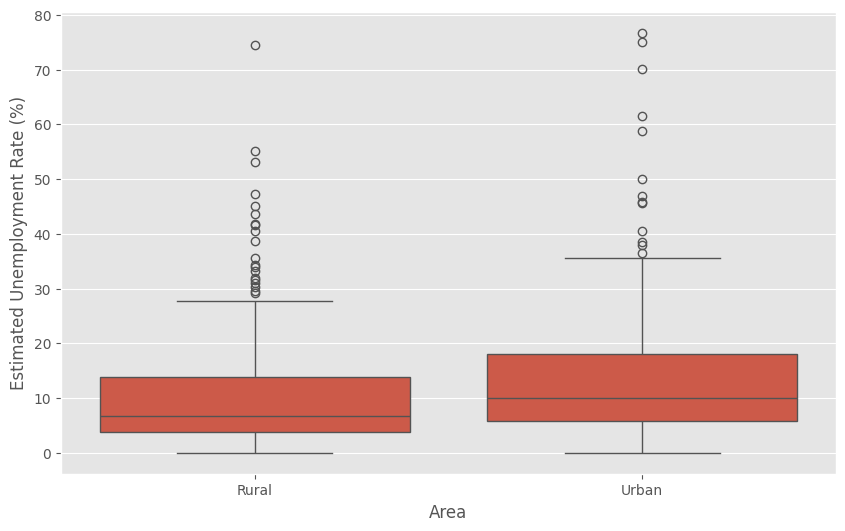

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(

x='Area',

y='Estimated Unemployment Rate (%)',

data=df

)

plt.show()

## Observations

- Dataset contains unemployment statistics for different Indian states.
- Missing values were handled by removing incomplete records.
- Some states consistently show higher unemployment rates.
- A noticeable increase in unemployment is observed after the COVID-19 outbreak.
- Labour participation and employment show meaningful relationships.

## Conclusion

This analysis highlights the impact of COVID-19 on unemployment across India. Region-wise and time-series analysis reveal significant differences among states. Visualizations provide useful insights for policymakers and researchers to understand employment trends and support data-driven decisions.